<a href="https://colab.research.google.com/github/suriyaksd-dotcom/FAKE-NEWS-DETECTION/blob/main/FAKE_NEWS_USING_BiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# BiLSTM Fake News Detection
# ---------------------------

# 1️⃣ Imports
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
# 2️⃣ Load Dataset
df = pd.read_csv("/content/drive/MyDrive/wel fake dataset/WELFake_Dataset.csv")  # your dataset path
print("Dataset shape:", df.shape)

# Assuming columns: 'text' and 'label'
df = df.dropna(subset=['text','label'])

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])  # 0 = Real, 1 = Fake

Dataset shape: (72134, 4)


In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 3️⃣ Split Dataset
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

In [ ]:
# 4️⃣ Tokenization & Padding
max_words = 10000
max_len = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

def encode_texts(texts):
    seq = tokenizer.texts_to_sequences(texts)
    seq = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    return np.array(seq)

X_train = encode_texts(train_texts)
X_val = encode_texts(val_texts)
y_train = np.array(train_labels)
y_val = np.array(val_labels)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dropout, Dense

# --- Hyperparameters ---
embedding_dim = 128
hidden_dim = 64
dropout_rate = 0.3

# max_words = vocabulary size
# max_len = sequence length of your padded input


# --- Build the BiLSTM model ---
model = Sequential()
model.add(Embedding(input_dim=max_words,
                    output_dim=embedding_dim,
                    input_shape=(max_len,)))

model.add(Bidirectional(LSTM(hidden_dim)))
model.add(Dropout(dropout_rate))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# --- Compile the model ---
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- View model summary ---
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 128, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6️⃣ Checkpoint Callback
checkpoint_path = "bilstm_checkpoint.h5"
checkpoint = ModelCheckpoint(
    checkpoint_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max'
)

In [ ]:
# 7️⃣ Train Model
epochs = 5
batch_size = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[checkpoint]
)

Epoch 1/5
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8973 - loss: 0.2270
Epoch 1: val_accuracy improved from -inf to 0.96193, saving model to bilstm_checkpoint.h5


1803/1803 ━━━━━━━━━━━━━━━━━━━━ 293s 160ms/step - accuracy: 0.8974 - loss: 0.2270 - val_accuracy: 0.9619 - val_loss: 0.1034
Epoch 2/5
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9748 - loss: 0.0711
Epoch 2: val_accuracy improved from 0.96193 to 0.96262, saving model to bilstm_checkpoint.h5


1803/1803 ━━━━━━━━━━━━━━━━━━━━ 293s 163ms/step - accuracy: 0.9748 - loss: 0.0711 - val_accuracy: 0.9626 - val_loss: 0.0928
Epoch 3/5
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9865 - loss: 0.0409
Epoch 3: val_accuracy improved from 0.96262 to 0.96657, saving model to bilstm_checkpoint.h5


1803/1803 ━━━━━━━━━━━━━━━━━━━━ 325s 164ms/step - accuracy: 0.9865 - loss: 0.0409 - val_accuracy: 0.9666 - val_loss: 0.0892
Epoch 4/5
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9941 - loss: 0.0186
Epoch 4: val_accuracy improved from 0.96657 to 0.97184, saving model to bilstm_checkpoint.h5


1803/1803 ━━━━━━━━━━━━━━━━━━━━ 318s 162ms/step - accuracy: 0.9941 - loss: 0.0187 - val_accuracy: 0.9718 - val_loss: 0.1032
Epoch 5/5
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9970 - loss: 0.0097
Epoch 5: val_accuracy did not improve from 0.97184
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 321s 162ms/step - accuracy: 0.9970 - loss: 0.0097 - val_accuracy: 0.9716 - val_loss: 0.1230


In [ ]:
# 8️⃣ Load Best Model
model = load_model(checkpoint_path)

In [ ]:
# -------------------- 9 EVALUATE MODEL --------------------

loss, accuracy = model.evaluate(X_val, y_val)

print("Test Accuracy:", accuracy)

451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9741 - loss: 0.0923
Test Accuracy: 0.9718427062034607


In [ ]:

# -------------------- 10 PREDICTIONS --------------------

y_pred = model.predict(X_test_pad)

y_pred = (y_pred > 0.5).astype(int)

451/451 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step


In [ ]:
from sklearn.metrics import classification_report

# -------------------- 11 CLASSIFICATION REPORT --------------------

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7010
           1       0.98      0.97      0.97      7409

    accuracy                           0.97     14419
   macro avg       0.97      0.97      0.97     14419
weighted avg       0.97      0.97      0.97     14419



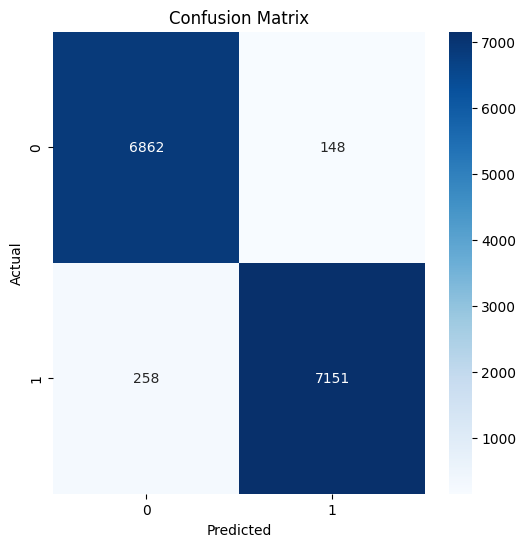

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 12 CONFUSION MATRIX --------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# 13 Predict New News Function
def predict_news(text):
    seq = encode_texts([text])
    pred = model.predict(seq)[0][0]
    label = "Fake" if pred > 0.5 else "Real"
    return label, pred

In [ ]:
# 14 Example Prediction
news = "Government announces new education policy."
label, prob = predict_news(news)
print(f"Prediction: {label}, Probability: {prob:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: Fake, Probability: 1.00


In [ ]:
#  Example Prediction
news = ".“The European Union has agreed to impose new sanctions on Russia over recent geopolitical tensions.."
label, prob = predict_news(news)
print(f"Prediction: {label}, Probability: {prob:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Prediction: Real, Probability: 0.35


In [ ]:
news = "Google’s DeepMind AI system has successfully predicted the structure of thousands of proteins.”.."
label, prob = predict_news(news)
print(f"Prediction: {label}, Probability: {prob:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction: Fake, Probability: 0.85


In [ ]:
news="“Amazon plans to hire 125,000 seasonal workers in the US for the holiday shopping season.”"
label, prob = predict_news(news)
print(f"Prediction: {label}, Probability: {prob:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: Real, Probability: 0.01
